In [16]:
!ls

ai-sage_Giga-Embeddings-instruct_1778889107.csv
ai-sage_Giga-Embeddings-instruct_BAAI_bge-reranker-v2-m3_1778887980.csv
ai-sage_Giga-Embeddings-instruct_BAAI_bge-reranker-v2-m3_retrievalFilter_1778874453.csv
ai-sage_Giga-Embeddings-instruct_Qwen_Qwen3-Reranker-0.6B_1778886110.csv
ai-sage_Giga-Embeddings-instruct_Qwen_Qwen3-Reranker-0.6B_retrievalFilter_1778880798.csv
sample_data
summary.xlsx


In [2]:
import os
import re
from glob import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
EVAL_DIR = Path.cwd()

FILENAME_RE = re.compile(r"^(?P<embed>.+?)(?:_(?P<reranker>BAAI[^_]+|.*?reranker[^_]*))?(?:_(?P<filter>retrievalFilter))?_(?P<ts>\d{10})\.csv$")

def parse_filename(path: Path) -> dict:
    """Best-effort parse of the timestamped CSV filename."""
    name = path.stem
    parts = name.split("_")
    ts = int(parts[-1]) if parts[-1].isdigit() else None
    has_filter = "retrievalFilter" in parts
    has_reranker = any("reranker" in p.lower() for p in parts)
    return {
        "file": path.name,
        "timestamp": pd.to_datetime(ts, unit="s") if ts else None,
        "reranker": has_reranker,
        "filter": has_filter,
    }

def list_runs(directory: Path = EVAL_DIR) -> pd.DataFrame:
    rows = []
    for path in sorted(directory.glob("*.csv")):
        meta = parse_filename(path)
        try:
            df = pd.read_csv(path)
            meta["entries"] = len(df)
        except Exception as exc:
            meta["entries"] = None
            meta["error"] = str(exc)
        meta["path"] = path
        rows.append(meta)
    return pd.DataFrame(rows)

runs_index = list_runs()
runs_index

,file,timestamp,reranker,filter,entries,path
0,ai-sage_Giga-Embeddings-instruct_1778889107.csv,2026-05-15 23:51:47,False,False,54,/content/ai-sage_Giga-Embeddings-instruct_1778...
1,ai-sage_Giga-Embeddings-instruct_BAAI_bge-rera...,2026-05-15 23:33:00,True,False,54,/content/ai-sage_Giga-Embeddings-instruct_BAAI...
2,ai-sage_Giga-Embeddings-instruct_BAAI_bge-rera...,2026-05-15 19:47:33,True,True,54,/content/ai-sage_Giga-Embeddings-instruct_BAAI...
3,ai-sage_Giga-Embeddings-instruct_Qwen_Qwen3-Re...,2026-05-15 23:01:50,True,False,54,/content/ai-sage_Giga-Embeddings-instruct_Qwen...
4,ai-sage_Giga-Embeddings-instruct_Qwen_Qwen3-Re...,2026-05-15 21:33:18,True,True,54,/content/ai-sage_Giga-Embeddings-instruct_Qwen...


In [4]:
CSV_PATH = EVAL_DIR / "ai-sage_Giga-Embeddings-instruct_Qwen_Qwen3-Reranker-0.6B_retrievalFilter_1778880798.csv"

df = pd.read_csv(CSV_PATH)
print(f"Загружен: {CSV_PATH.name}")
print(f"Записей: {len(df)}")
df.head(100)

Загружен: ai-sage_Giga-Embeddings-instruct_Qwen_Qwen3-Reranker-0.6B_retrievalFilter_1778880798.csv
Записей: 54


,initial_request,contract_type,classified_deal_type,classification_correct,retrieve_norms_latency_ms,total_gold,matched_total,precision@3,recall@3,hit@3,...,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20,required_sources,actual_sources
0,Я хочу продать оборудование другой компании и ...,договор купли-продажи,договор купли-продажи,1,6840.9,1,1,1.0000,1.0000,1,...,1.0000,1,0.9,1.0000,1,0.50,1.0000,1,ГК РФ ст.454-491,ГК РФ ст.454 | ГК РФ ст.486 | ГК РФ ст.491 | Г...
1,"У меня магазин, я продаю товары обычным людям ...",договор розничной купли-продажи,договор розничной купли-продажи,1,9320.9,8,5,0.6667,0.2500,1,...,0.2500,1,0.6,0.3750,1,0.40,0.6250,1,ГК РФ ст.454-491 | ФЗ О ЗАЩИТЕ ПРАВ ПОТРЕБИТЕЛ...,ГК РФ ст.492 | ГК РФ ст.454 | ФЗ О ЗАЩИТЕ ПРАВ...
2,Я продаю удочки через магазин обычным покупате...,договор розничной купли-продажи,договор розничной купли-продажи,1,17579.5,9,7,1.0000,0.2222,1,...,0.3333,1,0.8,0.5556,1,0.80,0.5556,1,ГК РФ ст.454-491 | ГК РФ ст.492-505 | ФЗ О ЗАЩ...,ФЗ О ЗАЩИТЕ ПРАВ ПОТРЕБИТЕЛЕЙ ст.26.1 | ГК РФ ...
3,"У меня интернет-магазин, покупатели заказывают...",договор розничной купли-продажи,договор розничной купли-продажи,1,13765.2,9,7,1.0000,0.2222,1,...,0.3333,1,0.8,0.3333,1,0.70,0.6667,1,ГК РФ ст.454-491 | ГК РФ ст.492-505 | ФЗ О ЗАЩ...,ФЗ О ЗАЩИТЕ ПРАВ ПОТРЕБИТЕЛЕЙ ст.26.1 | ГК РФ ...
4,Я хочу продать нежилое помещение и оформить пе...,договор продажи недвижимости,договор продажи недвижимости,1,8747.3,10,3,1.0000,0.2000,1,...,0.3000,1,0.6,0.3000,1,0.60,0.3000,1,ГК РФ ст.454-491 | ГК РФ ст.549-558 | ГК РФ ст...,ГК РФ ст.551 | ГК РФ ст.454 | ГК РФ ст.549 | Г...
5,Я хочу продать свою долю в недвижимости другом...,договор продажи недвижимости,договор продажи недвижимости,1,7678.0,12,3,1.0000,0.1667,1,...,0.1667,1,0.8,0.2500,1,0.55,0.2500,1,ГК РФ ст.454-491 | ГК РФ ст.549-558 | ГК РФ ст...,ГК РФ ст.454 | ГК РФ ст.549 | ГК РФ ст.553 | Г...
6,"Я продаю квартиру, но в ней живут или зарегист...",договор продажи недвижимости,договор продажи недвижимости,1,8251.1,13,3,1.0000,0.0769,1,...,0.1538,1,0.7,0.2308,1,0.60,0.2308,1,ГК РФ ст.454-491 | ГК РФ ст.549-558 | ГК РФ ст...,ГК РФ ст.549 | ГК РФ ст.558 | ГК РФ ст.551 | Г...
7,Я хочу бесплатно переоформить автомобиль на ро...,договор дарения,договор дарения,1,6791.1,1,1,1.0000,1.0000,1,...,1.0000,1,1.0,1.0000,1,0.50,1.0000,1,ГК РФ ст.572-582,ГК РФ ст.572 | ГК РФ ст.574 | ГК РФ ст.574 | Г...
8,Я хочу подарить земельный участок родственнику...,договор дарения,договор дарения,1,10712.6,9,2,1.0000,0.1111,1,...,0.1111,1,0.7,0.2222,1,0.35,0.2222,1,ГК РФ ст.572-582 | ГК РФ ст.8.1 | ГК РФ ст.130...,ГК РФ ст.574 | ГК РФ ст.574 | ГК РФ ст.572 | Г...
9,Я хочу подарить свою долю в квартире брату,договор дарения,договор дарения,1,7425.5,14,1,1.0000,0.0714,1,...,0.0714,1,0.9,0.0714,1,0.45,0.0714,1,ГК РФ ст.572-582 | ГК РФ ст.8.1 | ГК РФ ст.130...,ГК РФ ст.572 | ГК РФ ст.574 | ГК РФ ст.574 | Г...


In [5]:
print("Колонки:", list(df.columns))
print()

k_values = sorted({int(c.split("@")[1]) for c in df.columns if c.startswith("precision@")})
print(f"k значения: {k_values}")
print()

print(f"Среднее total_gold per entry: {df['total_gold'].mean():.1f}")
print(f"Среднее matched_total per entry: {df['matched_total'].mean():.1f}")
print(f"Среднее returned chunks (не в CSV) — см. логи запуска")

Колонки: ['initial_request', 'contract_type', 'classified_deal_type', 'classification_correct', 'retrieve_norms_latency_ms', 'total_gold', 'matched_total', 'precision@3', 'recall@3', 'hit@3', 'precision@5', 'recall@5', 'hit@5', 'precision@10', 'recall@10', 'hit@10', 'precision@20', 'recall@20', 'hit@20', 'required_sources', 'actual_sources']

k значения: [3, 5, 10, 20]

Среднее total_gold per entry: 5.7
Среднее matched_total per entry: 2.0
Среднее returned chunks (не в CSV) — см. логи запуска


In [6]:
metric_cols = [c for c in df.columns if "@" in c]
aggregate = df[metric_cols + ["classification_correct"]].mean()
aggregate["matched_total / total_gold"] = (df["matched_total"].sum() / df["total_gold"].sum())

print("=== Усреднённые метрики ===")
for k in k_values:
    print(f"  precision@{k:>2}: {aggregate[f'precision@{k}']*100:6.2f}%")
    print(f"  recall@{k:>2}:    {aggregate[f'recall@{k}']*100:6.2f}%")
    print(f"  hit@{k:>2}:       {aggregate[f'hit@{k}']*100:6.2f}%")
    print()

print(f"Classification accuracy: {aggregate['classification_correct']*100:6.2f}%")
print(f"Total matched / total gold: {aggregate['matched_total / total_gold']*100:6.2f}%")

=== Усреднённые метрики ===
  precision@ 3:  91.36%
  recall@ 3:     45.98%
  hit@ 3:       100.00%

  precision@ 5:  89.63%
  recall@ 5:     49.87%
  hit@ 5:       100.00%

  precision@10:  77.96%
  recall@10:     54.95%
  hit@10:       100.00%

  precision@20:  47.78%
  recall@20:     56.04%
  hit@20:       100.00%

Classification accuracy: 100.00%
Total matched / total gold:  34.30%


In [7]:
per_type = df.groupby("contract_type").agg(
    entries=("contract_type", "count"),
    classification_acc=("classification_correct", "mean"),
    **{f"recall@{k}": (f"recall@{k}", "mean") for k in k_values},
    **{f"precision@{k}": (f"precision@{k}", "mean") for k in k_values},
)

key_k = k_values[len(k_values) // 2] if k_values else 10
per_type = per_type.sort_values(f"recall@{key_k}")
per_type

,entries,classification_acc,recall@3,recall@5,recall@10,recall@20,precision@3,precision@5,precision@10,precision@20
contract_type,,,,,,,,,,
договор найма жилого помещения,2,1.0,0.180550,0.180550,0.180550,0.180550,1.000000,1.000000,1.000000,0.975000
договор пожизненного содержания с иждивением,1,1.0,0.100000,0.100000,0.200000,0.200000,1.000000,1.000000,0.700000,0.350000
договор проката,1,1.0,0.250000,0.250000,0.250000,0.250000,1.000000,1.000000,0.500000,0.250000
договор бытового подряда,1,1.0,0.250000,0.250000,0.250000,0.250000,0.666700,0.800000,0.900000,0.450000
договор продажи недвижимости,3,1.0,0.147867,0.206833,0.260267,0.260267,1.000000,1.000000,0.700000,0.583333
договор поднайма жилого помещения,2,1.0,0.291650,0.291650,0.291650,0.291650,1.000000,1.000000,0.900000,0.700000
договор безвозмездного пользования (ссуды),3,1.0,0.400667,0.400667,0.400667,0.400667,1.000000,1.000000,0.933333,0.516667
договор розничной купли-продажи,3,1.0,0.231467,0.305533,0.421300,0.615767,0.888900,0.800000,0.733333,0.633333
договор дарения,3,1.0,0.394167,0.394167,0.431200,0.431200,1.000000,0.933333,0.866667,0.433333


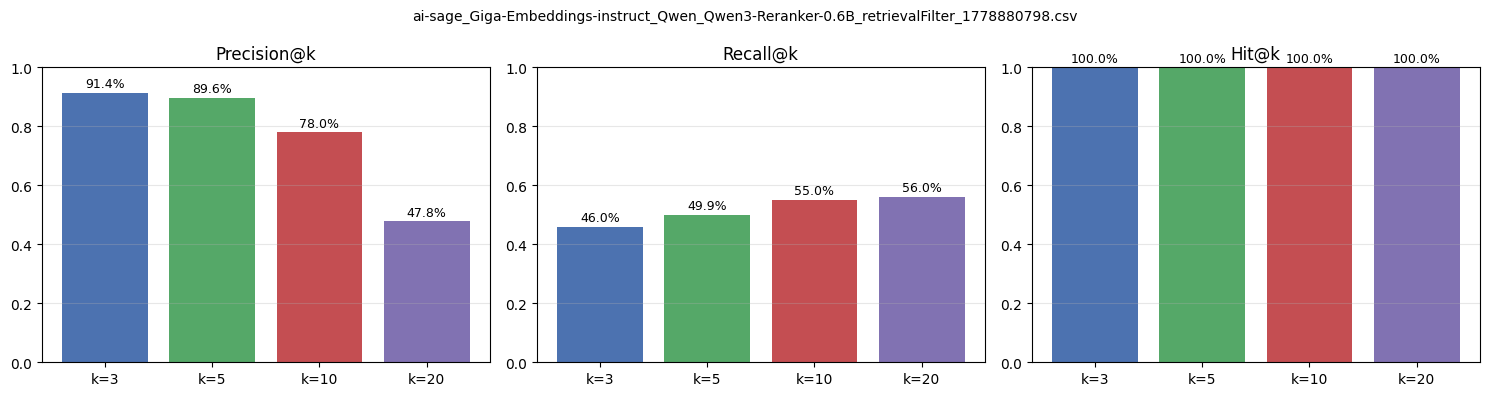

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ["precision", "recall", "hit"]
titles = ["Precision@k", "Recall@k", "Hit@k"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    values = [df[f"{metric}@{k}"].mean() for k in k_values]
    ax.bar(range(len(k_values)), values, color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"][:len(k_values)])
    ax.set_xticks(range(len(k_values)))
    ax.set_xticklabels([f"k={k}" for k in k_values])
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f"{v*100:.1f}%", ha="center", fontsize=9)

plt.suptitle(f"{CSV_PATH.name}", fontsize=10)
plt.tight_layout()
plt.show()

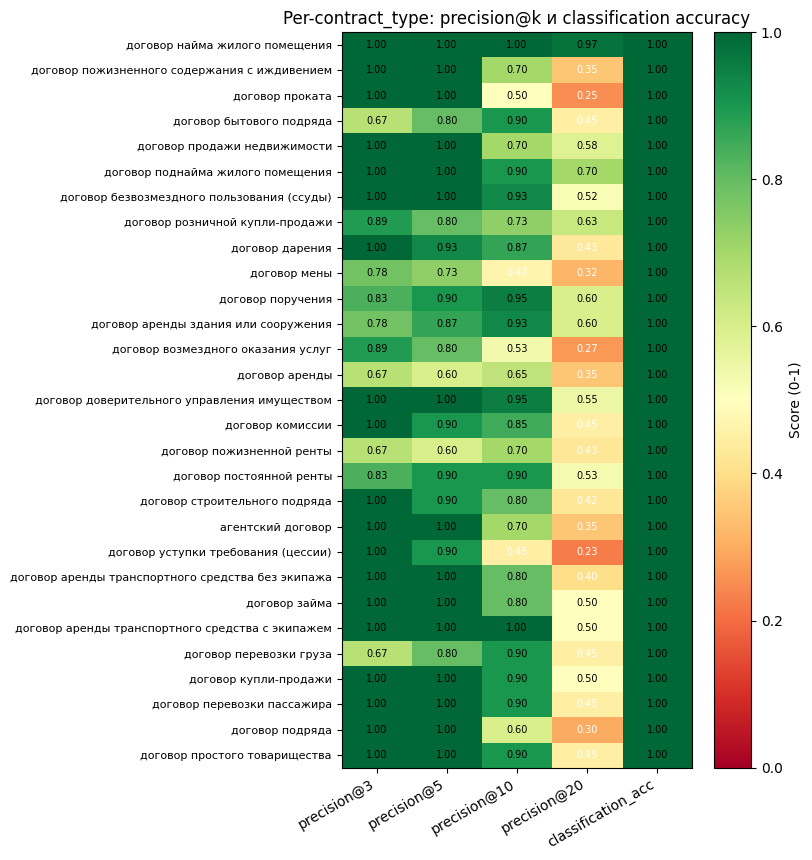

In [9]:
import numpy as np

heat_cols = [f"precision@{k}" for k in k_values] + ["classification_acc"]
heat_data = per_type[heat_cols].values

fig, ax = plt.subplots(figsize=(8, max(6, len(per_type) * 0.3)))
im = ax.imshow(heat_data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=30, ha="right")
ax.set_yticks(range(len(per_type)))
ax.set_yticklabels(per_type.index, fontsize=8)

# Цифры в ячейках
for i in range(len(per_type)):
    for j in range(len(heat_cols)):
        val = heat_data[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if val < 0.5 else "black", fontsize=7)

plt.colorbar(im, ax=ax, label="Score (0-1)")
ax.set_title("Per-contract_type: precision@k и classification accuracy")
plt.tight_layout()
plt.show()

In [10]:
worst = df.nsmallest(10, f"recall@{key_k}")[
    ["initial_request", "contract_type", "classified_deal_type",
     "classification_correct", "total_gold", "matched_total", f"recall@{key_k}", f"hit@{key_k}"]
]
print(f"=== Худшие 10 по recall@{key_k} ===")
worst.style.set_properties(subset=["initial_request"], **{"width": "400px"}) if hasattr(worst, "style") else worst

=== Худшие 10 по recall@10 ===


,initial_request,contract_type,classified_deal_type,classification_correct,total_gold,matched_total,recall@10,hit@10
9,Я хочу подарить свою долю в квартире брату,договор дарения,договор дарения,1,14,1,0.071400,1
11,Мы с другим собственником хотим обменяться квартирами,договор мены,договор мены,1,13,1,0.076900,1
15,"Я хочу сдать квартиру организации, чтобы там жили её сотрудники",договор аренды,договор аренды,1,11,1,0.090900,1
32,"Я хочу пустить человека жить в квартире бесплатно, но чтобы потом он освободил квартиру и вернул её",договор безвозмездного пользования (ссуды),договор безвозмездного пользования (ссуды),1,11,1,0.090900,1
14,"Я сдаю нежилое помещение бизнесу на длительный срок, нужно оформить договор и регистрацию",договор аренды здания или сооружения,договор аренды здания или сооружения,1,9,1,0.111100,1
27,"Я сдаю квартиру человеку на два года, нужно оформить договор и зарегистрировать ограничение",договор найма жилого помещения,договор найма жилого помещения,1,9,1,0.111100,1
31,Я хочу бесплатно передать компании нежилое помещение во временное пользование,договор безвозмездного пользования (ссуды),договор безвозмездного пользования (ссуды),1,9,1,0.111100,1
41,"Я хочу передать недвижимость управляющей компании, чтобы она управляла ею и сдавала её в мою пользу",договор доверительного управления имуществом,договор доверительного управления имуществом,1,9,1,0.111100,1
47,"Я как физическое лицо хочу сдать вещь в комиссионный магазин, чтобы они продали её от своего имени",договор комиссии,договор комиссии,1,7,1,0.142900,1
22,"Я хочу передать недвижимость другому лицу, а взамен получать от него постоянные выплаты",договор постоянной ренты,договор постоянной ренты,1,10,2,0.200000,1


In [ ]:
import re
from collections import defaultdict

ENTRY_RE = re.compile(r"^(.+?)\s+ст\.(.+)$")
RANGE_RE = re.compile(r"^\s*([\d.]+)\s*-\s*([\d.]+)\s*$")
SOURCE_NORMALIZE_PUNCT = re.compile(r"[\(\)\[\]\{\}\.,:;\"'«»]")
SOURCE_NORMALIZE_SPACE = re.compile(r"\s+")


def parse_source_list(text: str) -> list[tuple[str, str]]:
    """`'ГК РФ ст.454-491 | ФЗ О ЗПП ст.1'` → `[('ГК РФ', '454-491'), ('ФЗ О ЗПП', '1')]`."""
    if not isinstance(text, str) or not text.strip():
        return []
    out = []
    for entry in text.split(" | "):
        m = ENTRY_RE.match(entry.strip())
        if m:
            out.append((m.group(1).strip(), m.group(2).strip()))
    return out


def normalize_source(s: str) -> str:
    s = (s or "").replace("_", " ").lower()
    s = SOURCE_NORMALIZE_PUNCT.sub(" ", s)
    return SOURCE_NORMALIZE_SPACE.sub(" ", s).strip()


def source_matches(gold_clean: str, actual_clean: str) -> bool:
    if not gold_clean or not actual_clean:
        return False
    if gold_clean == actual_clean:
        return True
    return gold_clean in actual_clean or actual_clean in gold_clean


def parse_article_int(spec) -> int | None:
    """`'454' → 454`, `'26.1' → 261` (точка снимается)."""
    digits = re.sub(r"[^\d]", "", str(spec))
    return int(digits) if digits else None


def parse_required_spec(spec: str):
    """Возвращает `('range', lo, hi)` или `('single', value)` или None."""
    s = str(spec).strip()
    m = RANGE_RE.match(s)
    if m:
        lo = parse_article_int(m.group(1))
        hi = parse_article_int(m.group(2))
        if lo is not None and hi is not None and lo <= hi:
            return ("range", lo, hi)
        return None
    v = parse_article_int(s)
    return ("single", v) if v is not None else None


def spec_matches(parsed_spec, actual_value: int) -> bool:
    if parsed_spec is None:
        return False
    if parsed_spec[0] == "range":
        return parsed_spec[1] <= actual_value <= parsed_spec[2]
    return actual_value == parsed_spec[1]


def gold_spec_was_hit(req_source: str, req_spec: str, actual_pairs: list[tuple[str, str]]) -> bool | None:
    parsed = parse_required_spec(req_spec)
    if parsed is None:
        return None
    gold_clean = normalize_source(req_source)
    for a_source, a_article in actual_pairs:
        if not source_matches(gold_clean, normalize_source(a_source)):
            continue
        a_value = parse_article_int(a_article)
        if a_value is not None and spec_matches(parsed, a_value):
            return True
    return False


source_stats = defaultdict(lambda: {"hits": 0, "misses": 0, "examples": []})

for _, row in df.iterrows():
    required = parse_source_list(row.get("required_sources", ""))
    actual = parse_source_list(row.get("actual_sources", ""))
    for src, spec in required:
        result = gold_spec_was_hit(src, spec, actual)
        if result is None:
            continue
        bucket = "hits" if result else "misses"
        source_stats[src][bucket] += 1
        if not result and len(source_stats[src]["examples"]) < 5:
            source_stats[src]["examples"].append({
                "request": row["initial_request"][:80],
                "contract_type": row["contract_type"],
                "missed_spec": spec,
            })

rows = []
for src, stats in source_stats.items():
    total = stats["hits"] + stats["misses"]
    if total == 0:
        continue
    rows.append({
        "source": src,
        "total_gold_specs": total,
        "hits": stats["hits"],
        "misses": stats["misses"],
        "hit_rate": stats["hits"] / total,
    })

source_quality = pd.DataFrame(rows).sort_values("hit_rate")
print(f"Источников в анализе: {len(source_quality)}")
source_quality.style.format({"hit_rate": "{:.1%}"}).background_gradient(
    subset=["hit_rate"], cmap="RdYlGn", vmin=0, vmax=1
)

In [12]:
import re

TIMESTAMP_RE = re.compile(r"_(\d{10})$")
FILTER_TAG = "_retrievalFilter"
RERANKER_RE = re.compile(r"_([A-Za-z][A-Za-z0-9-]*_[A-Za-z0-9.-]*[Rr]eranker[A-Za-z0-9.-]*)$")

LATENCY_METRICS = ["latency_mean_ms", "latency_median_ms", "latency_p90_ms"]


def _short_model_name(full: str) -> str:
    if not full or full == "—":
        return full
    return full.split("/")[-1]


def parse_run_metadata(path: Path) -> dict:
    stem = path.stem
    ts_match = TIMESTAMP_RE.search(stem)
    timestamp = pd.NaT
    if ts_match:
        timestamp = pd.to_datetime(int(ts_match.group(1)), unit="s")
        stem = stem[: ts_match.start()]
    filter_enabled = stem.endswith(FILTER_TAG)
    if filter_enabled:
        stem = stem[: -len(FILTER_TAG)]
    rerank_match = RERANKER_RE.search(stem)
    if rerank_match:
        reranker = rerank_match.group(1).replace("_", "/", 1)
        embedder_raw = stem[: rerank_match.start()]
    else:
        reranker = None
        embedder_raw = stem
    embedder = embedder_raw.replace("_", "/", 1) if "_" in embedder_raw else embedder_raw
    return {
        "embedder_full": embedder,
        "reranker_full": reranker or "—",
        "embedder": _short_model_name(embedder),
        "reranker": _short_model_name(reranker or "—"),
        "filter": "on" if filter_enabled else "off",
        "timestamp": timestamp,
    }


def summarize_run(path: Path) -> dict:
    d = pd.read_csv(path)
    summary = parse_run_metadata(path)
    for col in [c for c in d.columns if "@" in c] + ["classification_correct"]:
        summary[col] = d[col].mean()
    if "retrieve_norms_latency_ms" in d.columns:
        latency = pd.to_numeric(d["retrieve_norms_latency_ms"], errors="coerce").dropna()
        if len(latency):
            summary["latency_mean_ms"] = float(latency.mean())
            summary["latency_median_ms"] = float(latency.median())
            summary["latency_p90_ms"] = float(latency.quantile(0.90))
    return summary


all_runs = pd.DataFrame([summarize_run(p) for p in sorted(EVAL_DIR.glob("*.csv"))])

header_cols = ["embedder", "reranker", "filter", "timestamp"]
meta_cols_to_drop = ["embedder_full", "reranker_full"]

percent_metrics = ["classification_correct"]
for k in k_values:
    percent_metrics += [f"recall@{k}", f"precision@{k}", f"hit@{k}"]
percent_metrics = [m for m in percent_metrics if m in all_runs.columns]

latency_metrics_present = [m for m in LATENCY_METRICS if m in all_runs.columns]

all_metric_rows = percent_metrics + latency_metrics_present

comparison = (
    all_runs
    .drop(columns=meta_cols_to_drop, errors="ignore")
    .set_index(header_cols)
    .reindex(columns=all_metric_rows)
    .T
)


def _highlight_best(row: pd.Series):
    """Зелёным помечаем лучший прогон в строке. Для latency лучшее = MIN,
    для остальных метрик — MAX. NaN в подсветке игнорируем."""
    is_latency = row.name in LATENCY_METRICS
    series = row.dropna()
    if series.empty:
        return ["" for _ in row]
    target = series.min() if is_latency else series.max()
    return ["background-color: green" if pd.notna(v) and v == target else "" for v in row]


styler = comparison.style.apply(_highlight_best, axis=1)

styler = styler.format("{:.2%}", subset=pd.IndexSlice[percent_metrics, :], na_rep="—")
if latency_metrics_present:
    styler = styler.format("{:.0f} ms", subset=pd.IndexSlice[latency_metrics_present, :], na_rep="—")
styler = styler.set_caption(
    "Сравнение прогонов · колонка = (embedder, reranker, filter, timestamp) · latency — меньше лучше"
)
styler

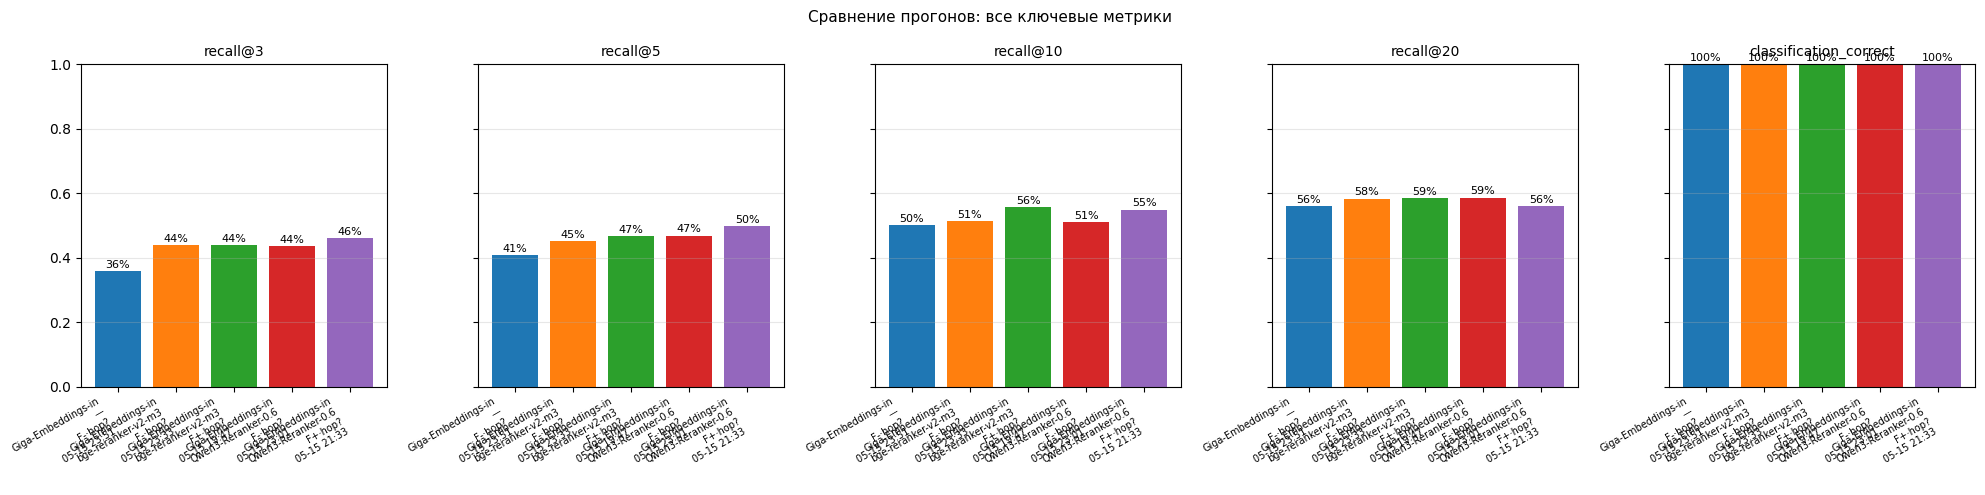

In [13]:
def short_label(row) -> str:
    embed = row.get("embedder") or "?"
    rerank = row.get("reranker") or "—"
    flt = "F+" if row.get("filter") == "on" else "F-"
    hop = row.get("reference_max_hop") or "—"
    hop_tag = f"hop{hop}" if hop != "—" else "hop?"
    ts = row.get("timestamp")
    ts_str = ts.strftime("%m-%d %H:%M") if pd.notna(ts) else "?"
    return f"{embed[:18]}\n{rerank[:18]}\n{flt}·{hop_tag}\n{ts_str}"

if len(all_runs) > 1:
    metrics_to_plot = [f"recall@{k}" for k in k_values] + ["classification_correct"]
    n_metrics = len(metrics_to_plot)

    fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 5), sharey=True)
    if n_metrics == 1:
        axes = [axes]

    labels = all_runs.apply(short_label, axis=1).tolist()
    colors = plt.cm.tab10.colors

    for ax, metric in zip(axes, metrics_to_plot):
        values = all_runs[metric].values
        bars = ax.bar(range(len(values)), values,
                      color=[colors[i % len(colors)] for i in range(len(values))])
        ax.set_xticks(range(len(values)))
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=7)
        ax.set_title(metric, fontsize=10)
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v * 100:.0f}%", ha="center", fontsize=8)

    plt.suptitle("Сравнение прогонов: все ключевые метрики", fontsize=11)
    plt.tight_layout()
    plt.show()

In [14]:
with pd.ExcelWriter(EVAL_DIR / "summary.xlsx", engine="openpyxl") as xl:
    aggregate.to_frame("value").to_excel(xl, sheet_name="overall")
    per_type.to_excel(xl, sheet_name="per_contract_type")
    if len(all_runs) > 1:
        comparison.to_excel(xl, sheet_name="run_comparison")
print(f"Сохранено: {EVAL_DIR / 'summary.xlsx'}")

Сохранено: /content/summary.xlsx


In [15]:
df = pd.read_csv(CSV_PATH)
per_type = df.groupby("contract_type").agg(
    entries=("contract_type", "count"),
    avg_recall_10=(f"recall@10", "mean"),
    avg_hit_10=(f"hit@10", "mean"),
    avg_matched=("matched_total", "mean"),
    avg_total_gold=("total_gold", "mean"),
).round(3)
per_type["coverage_status"] = per_type["avg_hit_10"].apply(lambda v: "OK" if v > 0.5 else ("partial" if v > 0 else "MISSING"))
per_type = per_type.sort_values("avg_hit_10", ascending=False)
per_type

,entries,avg_recall_10,avg_hit_10,avg_matched,avg_total_gold,coverage_status
contract_type,,,,,,
агентский договор,2,0.750,1.0,1.500,2.000,OK
договор аренды,2,0.545,1.0,1.000,6.000,OK
договор аренды здания или сооружения,3,0.466,1.0,1.667,6.000,OK
договор аренды транспортного средства без экипажа,1,1.000,1.0,2.000,2.000,OK
договор аренды транспортного средства с экипажем,1,1.000,1.0,2.000,2.000,OK
договор безвозмездного пользования (ссуды),3,0.401,1.0,1.000,7.000,OK
договор бытового подряда,1,0.250,1.0,2.000,8.000,OK
договор возмездного оказания услуг,3,0.500,1.0,2.000,4.667,OK
договор дарения,3,0.431,1.0,1.333,8.000,OK
